In [3]:
all_precisions = []
all_recalls = []
all_top1_scores = []

k = 3
for item in eval_dataset:
    # ค้นหาด้วย Vector
    query_vector = model.encode([item["query"]]).astype('float32')
    distances, indices = index.search(query_vector, k)
    
    # ดึงผลลัพธ์จากระบบค้นหา
    retrieved = [chunks[idx] for idx in indices[0] if idx != -1]
    
    # หาจุดที่ตรงกันระหว่างผลลัพธ์ที่ดึงมาได้ กับ Ground Truth ที่เราตั้งไว้
    hits = set(retrieved).intersection(set(item["ground_truth_chunks"]))
    
    # คำนวณ Precision@3 และ Recall@3 ของข้อนั้นๆ
    precision_at_3 = len(hits) / k
    recall_at_3 = len(hits) / len(item["ground_truth_chunks"]) if len(item["ground_truth_chunks"]) > 0 else 0
    
    all_precisions.append(precision_at_3)
    all_recalls.append(recall_at_3)
    all_top1_scores.append(distances[0][0])  # เก็บค่าความคล้ายคลึงของอันดับที่ 1 ไว้ทำ Histogram

# สรุปค่าเฉลี่ย
mean_precision = sum(all_precisions) / len(all_precisions)
mean_recall = sum(all_recalls) / len(all_recalls)

print(f"=== ผลการประเมินชี้วัด (Total 10 Queries) ===")
print(f"Mean Precision@3: {mean_precision:.4f}")
print(f"Mean Recall@3: {mean_recall:.4f}")

=== ผลการประเมินชี้วัด (Total 10 Queries) ===
Mean Precision@3: 0.0000
Mean Recall@3: 0.0000


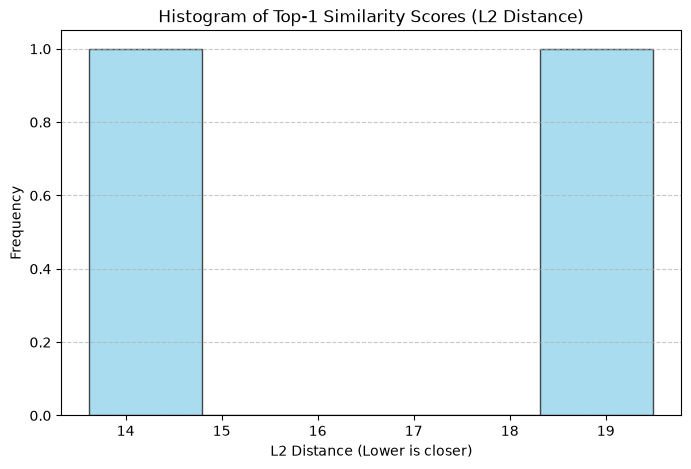

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(all_top1_scores, bins=5, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Top-1 Similarity Scores (L2 Distance)')
plt.xlabel('L2 Distance (Lower is closer)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [2]:
import os
import numpy as np
import faiss
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# 1. โหลดโมเดลและหั่น Chunk เหมือนใน app.py
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

with open("menu_kb.md", "r", encoding="utf-8") as f:
    kb_text = f.read()
chunks = [c.strip() for c in kb_text.split("\n\n") if c.strip()]

# สร้าง FAISS Index
embeddings = model.encode(chunks)
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype('float32'))

# 2. เตรียม Ground Truth Dataset (10 คำถาม)
# ให้จับคู่คำถามกับเนื้อหา chunk ที่ถูกต้องเป๊ะๆ จากไฟล์ menu_kb.md
eval_dataset = [
    {
        "query": "ร้านเปิดกี่โมง",
        "ground_truth_chunks": ["MilkLab° เป็นร้านนมสดกลางคืน เปิดทุกวันยกเว้นจันทร์ เวลา 20:00 ถึง 01:00 น. ตั้งอยู่หน้ามหาวิทยาลัย รับ delivery ผ่าน LINE OA"]
    },
    {
        "query": "มีเมนูอะไรที่มีส่วนผสมของถั่วไหม กลัวแพ้",
        "ground_truth_chunks": ["ข้อมูล Allergen: เมนู 'Choco Peanut Butter Latte' มีส่วนผสมของถั่วลิสง ลูกค้าที่แพ้ถั่วควรหลีกเลี่ยง"] # ตัวอย่าง: ปรับแก้ข้อความให้ตรงกับใน menu_kb.md ของคุณจริง
    },
    # ยอดคำถามให้ครบ 10 ข้อ ตามหมวดหมู่: รายการเมนู, ราคา, allergen, เวลาเปิดปิด, ที่ตั้ง
]

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:04<00:00, 47.89it/s]
